In [2]:
# import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
# load data
data = pd.read_csv(r'netflix_titles.csv')

# find which country has most netflix content
# which column will help to achieve this task

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [6]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
# clean data
data.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [18]:
data['country'].unique()

<ArrowStringArray>
[                                                        'United States',
                                                          'South Africa',
                                                                 'India',
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
                                                        'United Kingdom',
                                               'Germany, Czech Republic',
                                                                'Mexico',
                                                                'Turkey',
                                                             'Australia',
                                          'United States, India, France',
 ...
                        'Germany, United States, United Kingdom, Canada',
          'Canada, India, Thailand, United States, United Arab Emirates',
                             'United States, East Germany, West Germany',
              

In [12]:
# drop null
data= data.dropna(subset=['country'])

In [13]:
data.shape

(7976, 12)

In [14]:
data.isna().sum()

show_id            0
type               0
title              0
director        2225
cast             671
country            0
date_added         9
release_year       0
rating             3
duration           3
listed_in          0
description        0
dtype: int64

#### `check which country does the most content from`

In [22]:
data.groupby(['country'])['type'].value_counts().sort_values(ascending=False).head(10)

country         type   
United States   Movie      2058
India           Movie       893
United States   TV Show     760
United Kingdom  TV Show     213
                Movie       206
Japan           TV Show     169
South Korea     TV Show     158
Canada          Movie       122
Spain           Movie        97
Egypt           Movie        92
Name: count, dtype: int64

In [ ]:
data.groupby(['country'])['type'].value_counts().sort_values(ascending=False).head(10)

country         type   
United States   Movie      2058
India           Movie       893
United States   TV Show     760
United Kingdom  TV Show     213
                Movie       206
Japan           TV Show     169
South Korea     TV Show     158
Canada          Movie       122
Spain           Movie        97
Egypt           Movie        92
Name: count, dtype: int64

In [30]:
# make  new dataframe for viz
country_data = data.copy()
# step 2
country_data['country'] = country_data['country'].str.split(',')
# step 3
country_data=country_data.explode(column='country')

In [29]:
# verufy
country_data.shape

(10019, 12)

In [33]:
country_data['country'].unique()

<ArrowStringArray>
[ 'United States',   'South Africa',          'India',          'Ghana',
   'Burkina Faso', 'United Kingdom',        'Germany',       'Ethiopia',
 'Czech Republic',         'Mexico',
 ...
        'Jamaica',     'Kazakhstan',      'Lithuania',    'Afghanistan',
        'Somalia',          'Sudan',         'Panama',         'Uganda',
   'East Germany',     'Montenegro']
Length: 123, dtype: str

In [32]:
country_data['country']= country_data['country'].str.strip()

#### `check which country does the most content from`

In [34]:
country_data.groupby(['country'])['type'].value_counts().sort_values(ascending=False).head(12)

country         type   
United States   Movie      2752
India           Movie       962
United States   TV Show     938
United Kingdom  Movie       534
Canada          Movie       319
France          Movie       303
United Kingdom  TV Show     272
Japan           TV Show     199
Germany         Movie       182
Spain           Movie       171
South Korea     TV Show     170
Canada          TV Show     126
Name: count, dtype: int64

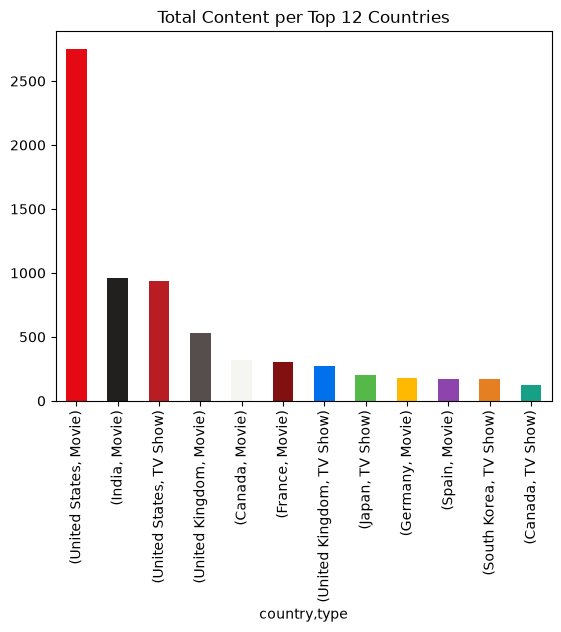

In [37]:
# make a vix
plt.title('Total Content per Top 12 Countries')
country_data.groupby(['country'])['type'].value_counts().sort_values(ascending=False).head(12).plot(kind='bar',color=['#E50914', '#221F1F', '#B81D24', '#564D4D', '#F5F5F1', '#831010', '#0071EB', '#54B948', '#FFB900', '#8E44AD', '#E67E22', '#16A085'])
plt.show()

## 🌍 Which Countries Dominate Netflix's Content Library?

To understand where Netflix's content comes from, both Movies and TV Shows 
were broken down by country of origin. Since many titles list multiple 
countries as co-producers, the country field was split and expanded so 
that each country receives fair credit for shared productions.

**Key Observations:**
- The **United States** overwhelmingly leads content production, with 
  **2,752 Movies** and **938 TV Shows** — far ahead of any other country.
- **India** ranks second, driven almost entirely by Movies (**962**), 
  reflecting the strength of its film industry (Bollywood) over TV content.
- The **United Kingdom**, **Canada**, and **France** follow, each 
  contributing a meaningful but much smaller share.
- Interestingly, countries like **Japan** and **South Korea** appear 
  primarily through **TV Shows** rather than Movies — hinting at their 
  strength in series-based content (anime, K-dramas).

This sets the stage for the next part of the story: how this country-wise 
content mix has shifted over time as Netflix expanded globally.